# Formula :- (Xi - Xbar) / std

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('Social_Network_Ads.csv')

In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [5]:
df = df.iloc[:,2:]

In [6]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


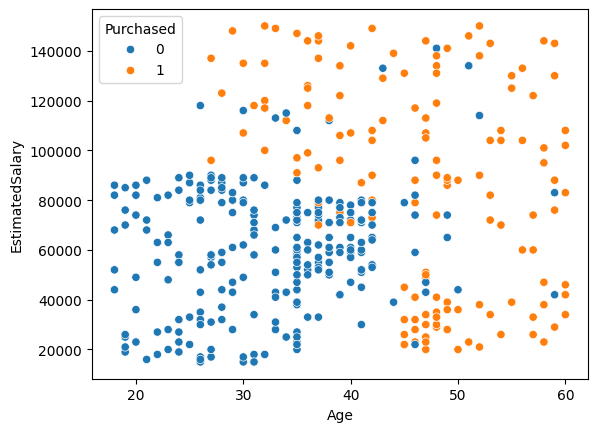

In [9]:
sns.scatterplot(x = 'Age', y = 'EstimatedSalary', data = df, hue = 'Purchased')
plt.show()

## Trian-Test-Split

In [21]:
X = df.iloc[:,:2]
y = df['Purchased']

In [22]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [24]:
scaler = StandardScaler()

In [25]:
scaler.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [29]:
scaled_x_train = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)
scaled_x_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [30]:
scaler.mean_

array([3.7871875e+01, 7.0281250e+04])

In [32]:
scaled_x_train['Age'].mean()

-2.7755575615628914e-16

In [ ]:
X_train.describe()

In [34]:
scaled_x_train.describe()

,Age,EstimatedSalary
count,3.200000e+02,3.200000e+02
mean,-2.775558e-16,1.110223e-17
std,1.001566e+00,1.001566e+00
min,-1.949836e+00,-1.608102e+00
25%,-7.723913e-01,-7.935968e-01
50%,-8.554870e-02,2.090805e-02
75%,6.994143e-01,5.154289e-01
max,2.171220e+00,2.318975e+00


## Effect of Scaling

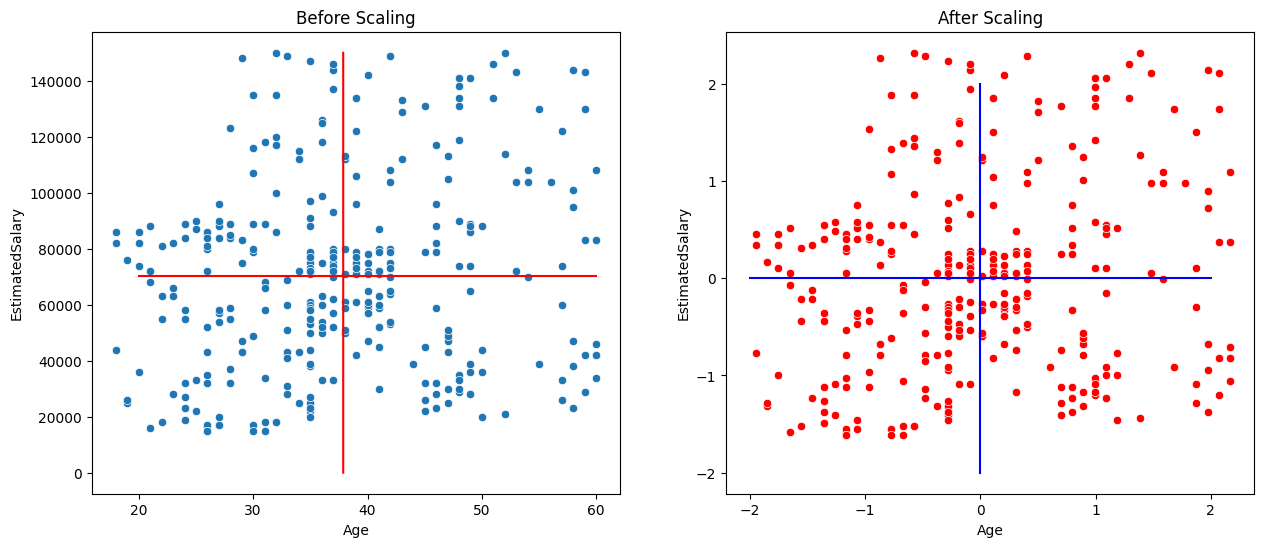

In [55]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.title("Before Scaling")
sns.scatterplot(x = "Age", y = "EstimatedSalary", data = X_train)
plt.plot([X_train['Age'].mean() for i in range(0,150000)],[i for i in range(150000)], c = 'red')
plt.plot([i for i in range(20,61)],[X_train['EstimatedSalary'].mean() for i in range(20,61)], c = 'red')

plt.subplot(1,2,2)
plt.title("After Scaling")
sns.scatterplot(x = "Age", y = "EstimatedSalary", data = scaled_x_train, color = 'red')
plt.plot([scaled_x_train['Age'].mean() for i in range(-2,3)],[i for i in range(-2,3)], c = 'blue')
plt.plot([i for i in range(-2,3)],[scaled_x_train['EstimatedSalary'].mean() for i in range(-2,3)], c = 'blue')

plt.show()

## Probability Distribution function on both the features (PDF)

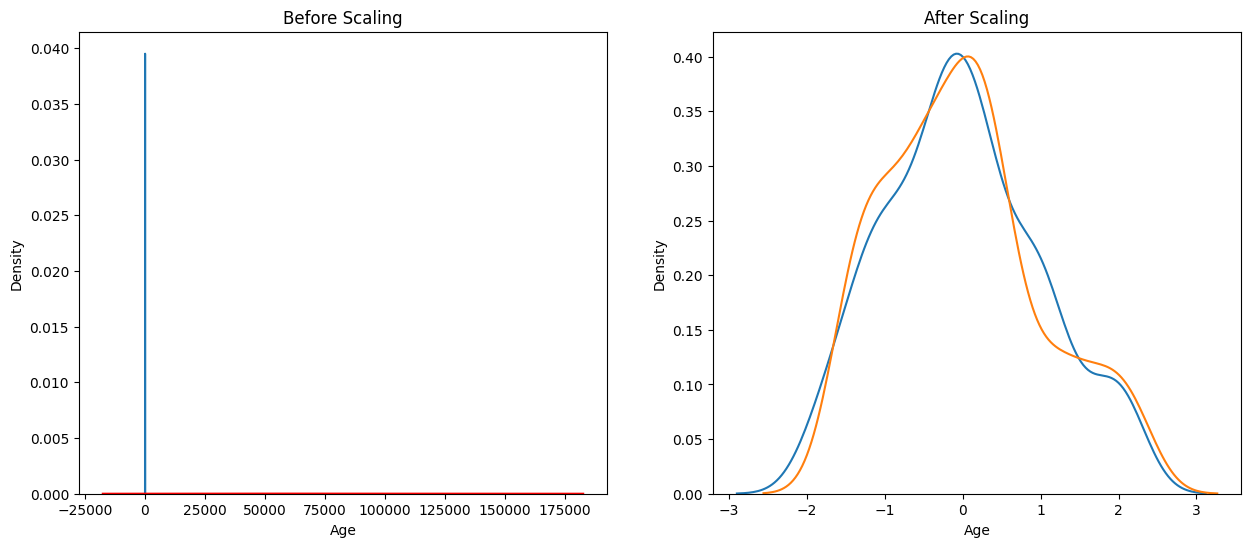

In [64]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.title("Before Scaling")
sns.kdeplot(X_train["Age"])
sns.kdeplot(X_train["EstimatedSalary"], color = 'red')

plt.subplot(1,2,2)
plt.title('After Scaling')
sns.kdeplot(scaled_x_train['Age'])
sns.kdeplot(scaled_x_train['EstimatedSalary'])

plt.show()

## Comparison of Distributions

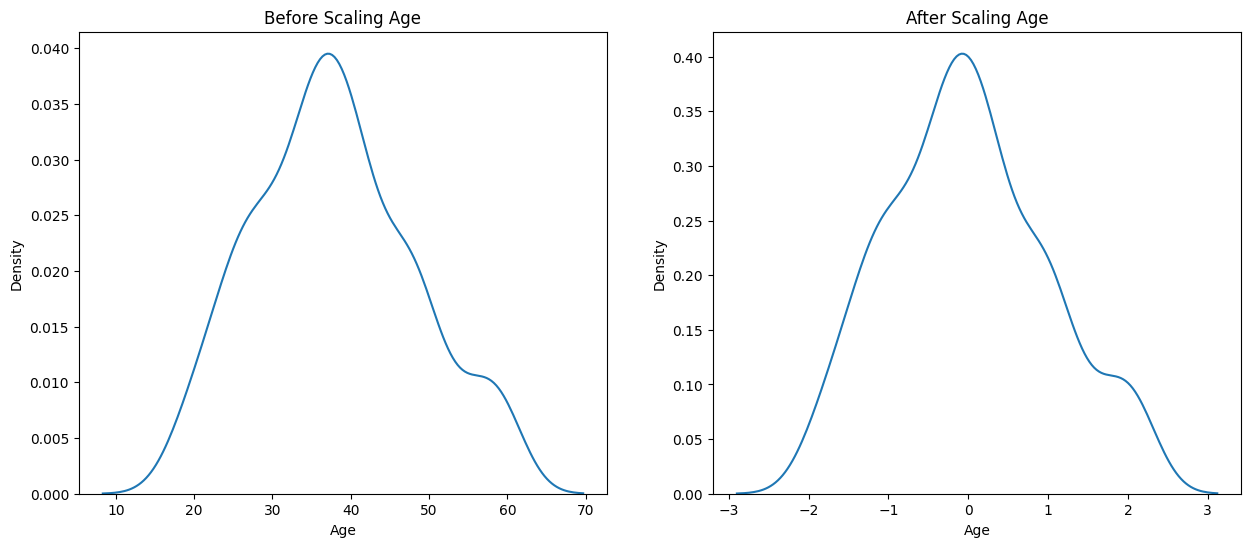

In [68]:
plt.figure(figsize=(15,6))

plt.subplot(1,2,1)
plt.title("Before Scaling Age")
sns.kdeplot(X_train["Age"])

plt.subplot(1,2,2)
plt.title("After Scaling Age")
sns.kdeplot(scaled_x_train["Age"])

plt.show()

## Why Scaling is Important

In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [71]:
l1 = LogisticRegression()

In [72]:
l1.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [74]:
accuracy_score(y_test,l1.predict(X_test)) * 100

88.75

In [75]:
l2 = LogisticRegression()

In [76]:
l2.fit(scaled_x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [78]:
accuracy_score(y_test,l2.predict(scaled_x_test)) * 100

86.25

In [87]:
new = pd.DataFrame({
    'Age':[120,140,150],
    'EstimatedSalary':[220000,250000,300000],
    'Purchased':[1,1,1]
})

In [88]:
X_train = pd.concat([X_train,new], ignore_index=True)

In [80]:
X_train.describe()

,Age,EstimatedSalary
count,320.000000,320.00000
mean,37.871875,70281.25000
std,10.207525,34430.55286
min,18.000000,15000.00000
25%,30.000000,43000.00000
50%,37.000000,71000.00000
75%,45.000000,88000.00000
max,60.000000,150000.00000


In [89]:
X_train.shape

(323, 3)

In [97]:
X_train_scaled = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns)

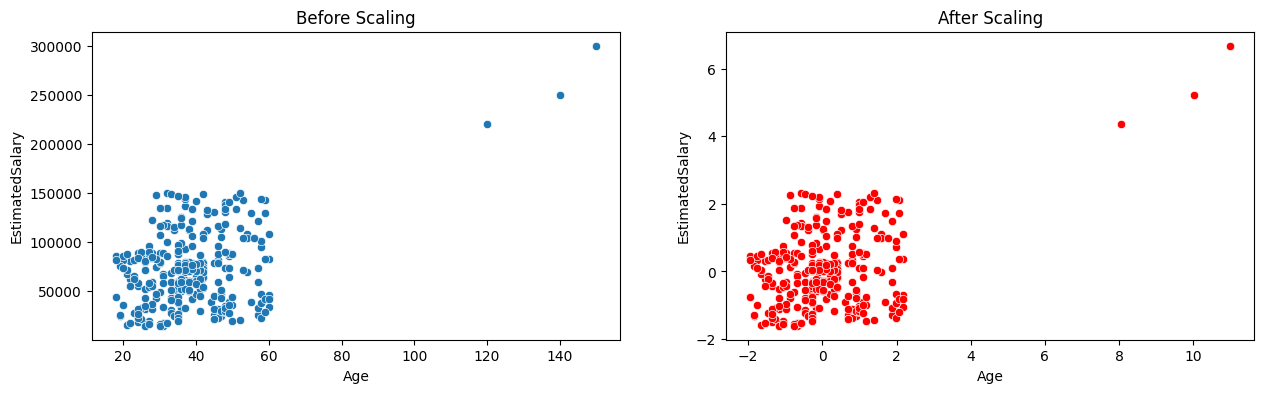

In [100]:
plt.figure(figsize=(15,4))

plt.subplot(1,2,1)
plt.title("Before Scaling")
sns.scatterplot(x = "Age", y = "EstimatedSalary", data = X_train)

plt.subplot(1,2,2)
plt.title("After Scaling")
sns.scatterplot(x = "Age", y = "EstimatedSalary", data = X_train_scaled, c = 'red')

plt.show()